In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.coupling import apply_node_lesions, plot_lesioned_coupling
from kuramoto.simulation import KuramotoParams
from kuramoto.analysis import (
    order_parameter, 
    compute_effective_coupling, 
    avg_effective_coupling,
    functional_connectivity,
    R_link,
)
from kuramoto.adjoint import (
    grads_final_R,
    grads_mean_R,
    node_importance_from_gradK,
    grads_final_R_alpha,
    grads_mean_R_alpha,
    plot_basic_grads,
    plot_advanced_grads,
)
from kuramoto.plotting import plot_2d, plot_coupling_matrix, set_plot_settings
from kuramoto.network import (
    create_cortical_graph,
    plot_graph_metrics,
    get_graph_metrics,
    plot_metric,
)
from kuramoto.experiments import run_lesion_study

import networkx as nx
from pathlib import Path

from jax import numpy as jnp

set_plot_settings()

# Import connectome
CONN_PATH = Path("..\\data\\OASIS_N272\\sub-OAS30001_ses-d0757_atlas-L2018_res-scale3_conndata-network_connectivity.graphml")
G = nx.read_graphml(CONN_PATH)

SEED = 42
K = 4

T_END = 20.0
dt = 0.1

RNG = np.random.default_rng(SEED)

In [2]:
# Run sim
nodes = sorted(G.nodes())
A_bin = nx.to_numpy_array(G, nodelist=nodes)
A_density = nx.to_numpy_array(G, nodelist=nodes, weight="normalized_fiber_density")

# Normalize to 0-1 
A_density = A_density / A_density.max()

G_bin = nx.from_numpy_array(A_bin)
G_density = nx.from_numpy_array(A_density)

ncols, nrows = A_density.shape

N = A_density.shape[0]

cfg = SimulationConfig(
    coupling=CouplingConfig(
        K_matrix=A_density * K,
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=SEED,
)

sim = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

grid_shape = sim.grid.shape

# Run base simulation
res_base = sim.run((0, T_END), dt, rng=RNG)

# Postprocess
R_list, _ = order_parameter(res_base['theta'])

K_eff_avg = avg_effective_coupling(sim.results["theta"], sim.coupling.K)
G_eff = create_cortical_graph(K_eff_avg, omega=sim.params.omega)

C_avg = functional_connectivity(sim.results["theta"], dt=dt)
G_C_avg = create_cortical_graph(C_avg, omega=sim.params.omega)

In [3]:
graph_metrics = get_graph_metrics(G)
graph_metrics_eff = get_graph_metrics(G_eff)
graph_metrics_C_avg = get_graph_metrics(G_C_avg)

# plot_graph_metrics(graph_metrics,grid_shape=grid_shape,title="Base coupling network metrics")
# plot_graph_metrics(graph_metrics_eff,grid_shape=grid_shape,title="Effective coupling network metrics")
# plot_graph_metrics(graph_metrics_C_avg,grid_shape=grid_shape,title="Functional connectivity network metrics")

### 2) Adjoint metrics

In [4]:
t0, t1 = 0.0, T_END
ts = jnp.arange(t0+dt, t1 + dt / 2, dt)
ts = ts[ts <= t1]

g = grads_final_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=[T_END])
g_avg = grads_mean_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=ts)

# plot_basic_grads(g,grid_shape,title="Basic gradients (J = R_final)")
# plot_basic_grads(g_avg,grid_shape,title="Basic gradients (J = R_mean)")

In [5]:
I_mean = node_importance_from_gradK(sim.params.K, g_avg.K)

alpha0 = jnp.zeros((sim.grid.N,), dtype=sim.params.K.dtype)
dRm_dalpha = grads_mean_R_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)

#Statistics
print(f"  max I_mean: {float(np.max(I_mean)):.6e}")
print(f"  max |dRm/dalpha| = {float(np.max(np.abs(dRm_dalpha))):.6e}")

#Plot
# plot_advanced_grads(dRf_dalpha, I_final, grid_shape, title="Node importance (J = R_final)")
# plot_advanced_grads(dRm_dalpha, I_mean, grid_shape, title="Node importance (J = R_mean)")

  max I_final: 5.318549e-02
  max I_mean: 4.243138e-02
  max |dRf/dalpha| = 8.013231e-02
  max |dRm/dalpha| = 4.749773e-02


## Lesion Studies

In [63]:
# Assemble all metrics into a single dictionary
metrics = {
    "deg_base": graph_metrics["deg_cent"],
    "deg_eff": graph_metrics_eff["deg_cent"],
    "closeness_base": graph_metrics["closeness"],
    "closeness_eff": graph_metrics_eff["closeness"],
    "betweenness_base": graph_metrics["betweenness"],
    "betweenness_eff": graph_metrics_eff["betweenness"],
    "eigenvector_base": graph_metrics["eigenvector"],
    "eigenvector_eff": graph_metrics_eff["eigenvector"],
    "eigenvector_C_avg": graph_metrics_C_avg["eigenvector"],
    "I_mean_base": I_mean,
    # "dRm_dalpha": dRm_dalpha,
}

N_RANDOM_REPEATS = 20

K_base = sim.coupling.K

### Single metric lesion study

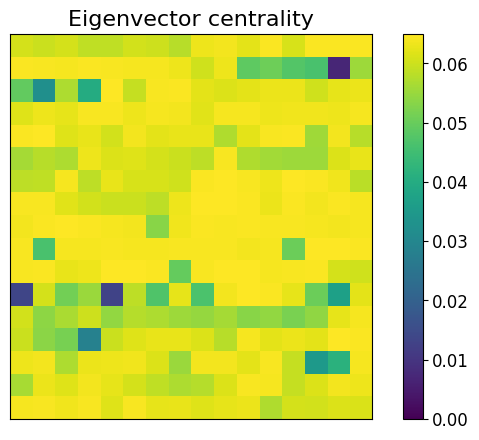

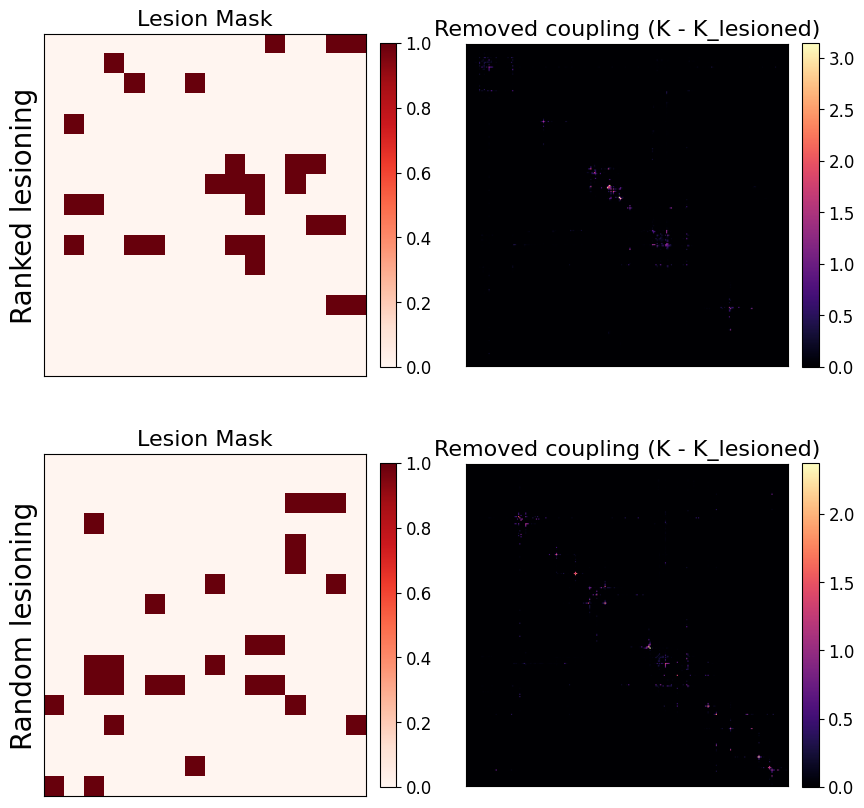

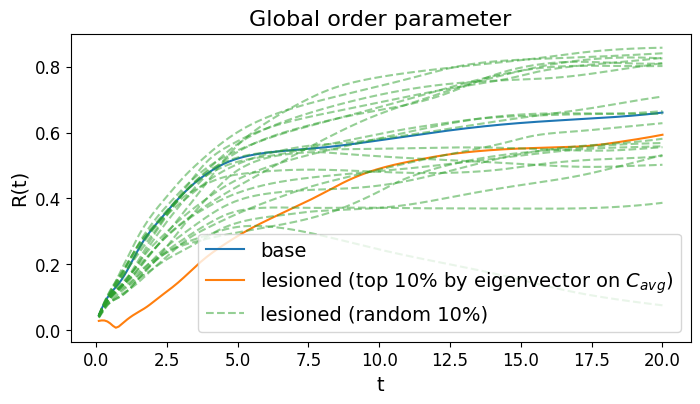

In [56]:
metric = graph_metrics_C_avg["eigenvector"]

plot_metric(metric, grid_shape, "Eigenvector centrality")

lesion_frac = 0.10
lesion_strength = 1.0 # lesion strength (1.0 = remove all connections)

# Lesion top x% of nodes by metric
res_ranked_lesion, alpha_ranked, K_lesioned_ranked = run_lesion_study(sim, metric, lesion_frac, lesion_strength, T_END, dt, 42)


# Lesion 10% of nodes randomly
R_random_lesion = np.zeros((len(ts), N_RANDOM_REPEATS))
for i in range(N_RANDOM_REPEATS):
    res_random_lesion, alpha_random, K_lesioned_random = run_lesion_study(sim, "random", lesion_frac, lesion_strength, T_END, dt, 42+i)
    R_random_lesion[:, i] = order_parameter(res_random_lesion["theta"])[0]


# Show lesioning
fig, axs = plt.subplots(2,2,figsize=(10,10))
plot_lesioned_coupling(alpha_ranked, K_base, K_lesioned_ranked, grid_shape, axs=axs[0,:])
plot_lesioned_coupling(alpha_random, K_base, K_lesioned_random, grid_shape, axs=axs[1,:])
axs[0,0].set_ylabel("Ranked lesioning",fontsize=20)
axs[1,0].set_ylabel("Random lesioning",fontsize=20)

# Compare R vs t for base and lesioned sim
R_base, _ = order_parameter(res_base["theta"])
R_ranked_lesion, _ = order_parameter(res_ranked_lesion["theta"])
ts = res_base["ts"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, R_base, label="base")
ax.plot(ts, R_ranked_lesion, label=f"lesioned (top {lesion_frac:.0%} by eigenvector on $C_{{avg}}$)")
for i in range(N_RANDOM_REPEATS):
    if i == 0:
        ax.plot(ts, R_random_lesion[:, i], label=f"lesioned (random {lesion_frac:.0%})", linestyle="--", color="C2", alpha=0.5)
    else:
        ax.plot(ts, R_random_lesion[:, i], linestyle="--", color="C2", alpha=0.5)
ax.set_xlabel("t")
ax.set_ylabel("R(t)")
ax.set_title("Global order parameter")
ax.legend()
plt.show()

Text(0.5, 0.98, 'R vs degradation for ranked vs random lesioning')

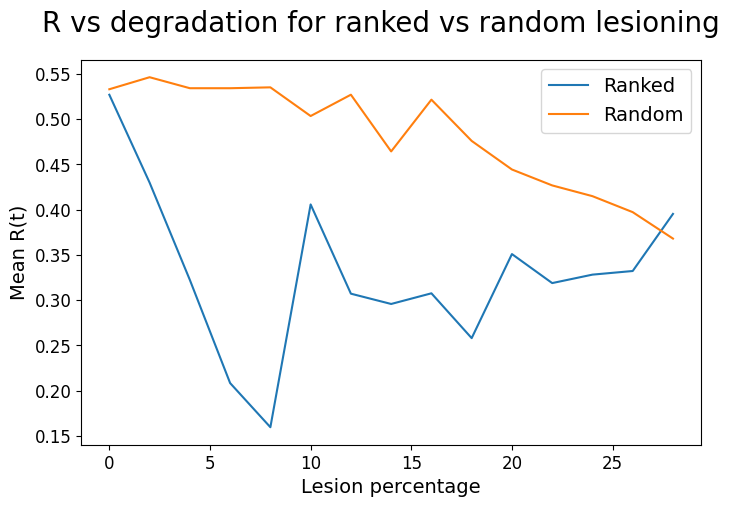

In [57]:
# Compute R final/ R_avg vs lesion %
lesion_fracs = np.arange(0, 0.3, 0.02)

R_final_ranked = []
R_avg_ranked = []
R_final_random = []
R_avg_random = []

for lesion_frac in lesion_fracs:
    res_ranked_lesion, alpha_ranked, K_lesioned_ranked = run_lesion_study(sim, metric, lesion_frac, lesion_strength, T_END, dt, SEED=42)
    R_ranked_lesion, _ = order_parameter(res_ranked_lesion["theta"])

    R_random_lesion = np.zeros((len(ts), N_RANDOM_REPEATS))
    for i in range(N_RANDOM_REPEATS):
        res_random_lesion, alpha_random, K_lesioned_random = run_lesion_study(sim, "random", lesion_frac, lesion_strength, T_END, dt, SEED=42+i)
        R_random_lesion[:, i], _ = order_parameter(res_random_lesion["theta"])
    R_random_lesion = np.mean(R_random_lesion, axis=1)

    R_avg_ranked.append(np.mean(R_ranked_lesion))
    R_avg_random.append(np.mean(R_random_lesion))

fig, ax = plt.subplots(1,1, figsize=(8, 5))
ax.plot(lesion_fracs*100, R_avg_ranked, label="Ranked")
ax.plot(lesion_fracs*100, R_avg_random, label="Random")
ax.set_xlabel("Lesion percentage")
ax.set_ylabel("Mean R(t)")
ax.legend()
fig.suptitle("R vs degradation for ranked vs random lesioning")

In [58]:
# Compute node importance metric scores
# 1) Area under degradation curve (AUC) - Lower AUC means better metric (performance degrades faster)
AUC_ranked = np.trapezoid(R_avg_ranked, lesion_fracs)
AUC_random = np.trapezoid(R_avg_random, lesion_fracs)

# 2) Area between random and ranked curves (ABC) - higher ABC means better metric (outperforms random lesioning)
ABC = AUC_random - AUC_ranked

print(f"AUC_ranked: {AUC_ranked:.4f}")
print(f"AUC_random: {AUC_random:.4f}")
print(f"ABC: {ABC:.4f}")

AUC_ranked: 0.0897
AUC_random: 0.1355
ABC: 0.0458


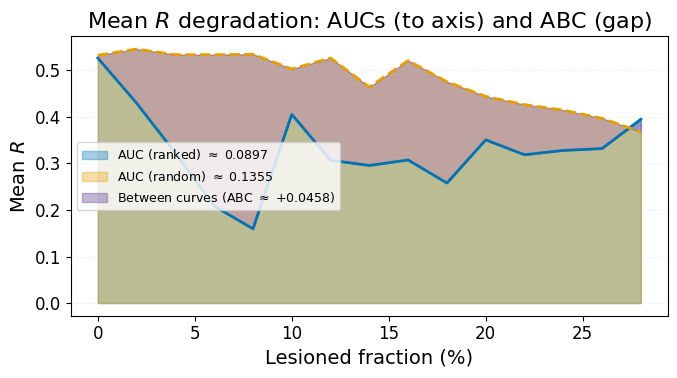

In [59]:
x = np.asarray(lesion_fracs, dtype=float)

x_plot = x * 100
x_label = "Lesioned fraction (%)"

Rr = np.asarray(R_avg_ranked, dtype=float)
Rm = np.asarray(R_avg_random, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))

# 1) Area to axis ≈ AUC_ranked (trapezoid in f)
ax.fill_between(
    x_plot, 0, Rr, alpha=0.35, color="#0072B2",
    label=rf"AUC (ranked) $\approx$ {AUC_ranked:.4f}",
)
# 2) Area to axis ≈ AUC_random
ax.fill_between(
    x_plot, 0, Rm, alpha=0.35, color="#E69F00",
    label=rf"AUC (random) $\approx$ {AUC_random:.4f}",
)

# 3) Strip between curves: geometric picture of ABC = ∫ (R_random − R_ranked) df
#    (if the curves cross, use signed chunks — see note below)
ax.fill_between(
    x_plot, Rr, Rm, alpha=0.4, color="#6B4C9A",
    label=rf"Between curves (ABC $\approx$ {ABC:+.4f})",
)

ax.plot(x_plot, Rr, color="#0072B2", lw=2, zorder=5)
ax.plot(x_plot, Rm, color="#E69F00", lw=2, ls="--", zorder=5)

ax.set_xlabel(x_label)
ax.set_ylabel(r"Mean $R$")
ax.set_title("Mean $R$ degradation: AUCs (to axis) and ABC (gap)")
ax.grid(True, axis="y", alpha=0.3, ls=":")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

### Evaluate on all metrics

In [65]:
# Run lesion study for each metric
metric_scores = {}
for metric_name, metric in metrics.items():
    print(f"Evaluating {metric_name}...")

    R_final_ranked = []
    R_avg_ranked = []
    R_final_random = []
    R_avg_random = []
    for lesion_frac in lesion_fracs:
        res_ranked_lesion, alpha_ranked, K_lesioned_ranked = run_lesion_study(sim, metric, lesion_frac, lesion_strength, T_END, dt, SEED=42)
        R_ranked_lesion, _ = order_parameter(res_ranked_lesion["theta"])

        R_random_lesion = np.zeros((len(ts), N_RANDOM_REPEATS))
        for i in range(N_RANDOM_REPEATS):
            res_random_lesion, alpha_random, K_lesioned_random = run_lesion_study(sim, "random", lesion_frac, lesion_strength, T_END, dt, SEED=42+i)
            R_random_lesion[:, i], _ = order_parameter(res_random_lesion["theta"])
        R_random_lesion = np.mean(R_random_lesion, axis=1)

        R_final_ranked.append(R_ranked_lesion[-1])
        R_avg_ranked.append(np.mean(R_ranked_lesion))
        R_final_random.append(R_random_lesion[-1])
        R_avg_random.append(np.mean(R_random_lesion))

    # Metric scores
    AUC_ranked = np.trapezoid(R_avg_ranked, lesion_fracs)
    AUC_random = np.trapezoid(R_avg_random, lesion_fracs)
    ABC = AUC_random - AUC_ranked

    metric_scores[metric_name] = {
        "AUC_ranked": AUC_ranked,
        "AUC_random": AUC_random,
        "ABC": ABC,
        "R_final_ranked": R_final_ranked,
        "R_avg_ranked": R_avg_ranked,
        "R_final_random": R_final_random,
        "R_avg_random": R_avg_random,
    }

Evaluating deg_base...
Evaluating deg_eff...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating I_mean_base...


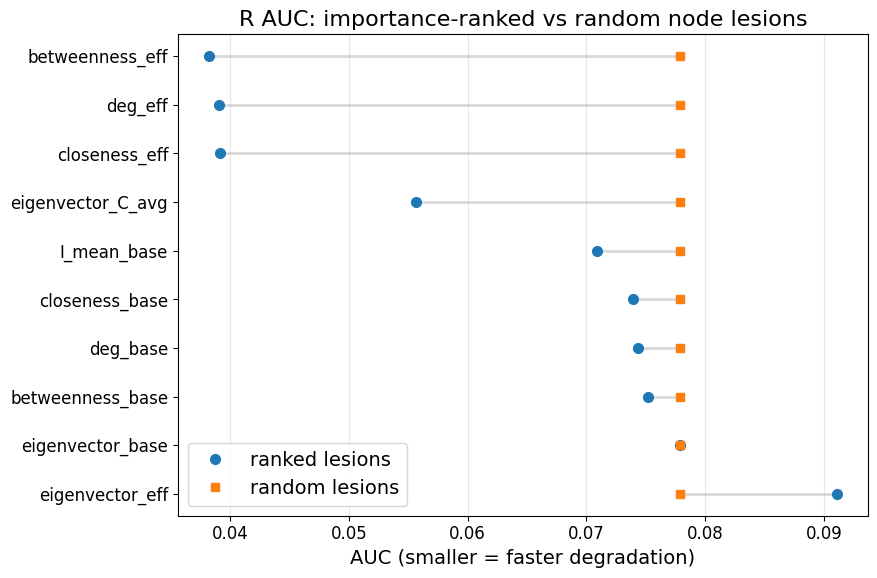

In [66]:
metrics = list(metric_scores.keys())
order = sorted(metrics, key=lambda m: metric_scores[m]["ABC"])

y = np.arange(len(order))
auc_r = np.array([metric_scores[m]["AUC_ranked"] for m in order])
auc_rand = np.array([metric_scores[m]["AUC_random"] for m in order])

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(order))))
ax.hlines(y, np.minimum(auc_r, auc_rand), np.maximum(auc_r, auc_rand), color="0.85", lw=2, zorder=0)
ax.plot(auc_r, y, "o", ms=7, label="ranked lesions", zorder=2, color="C0")
ax.plot(auc_rand, y, "s", ms=6, label="random lesions", zorder=2, color="C1")
ax.set_yticks(y, order)
ax.set_xlabel("AUC (smaller = faster degradation)")
ax.set_title("R AUC: importance-ranked vs random node lesions")
ax.legend(loc="lower left")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

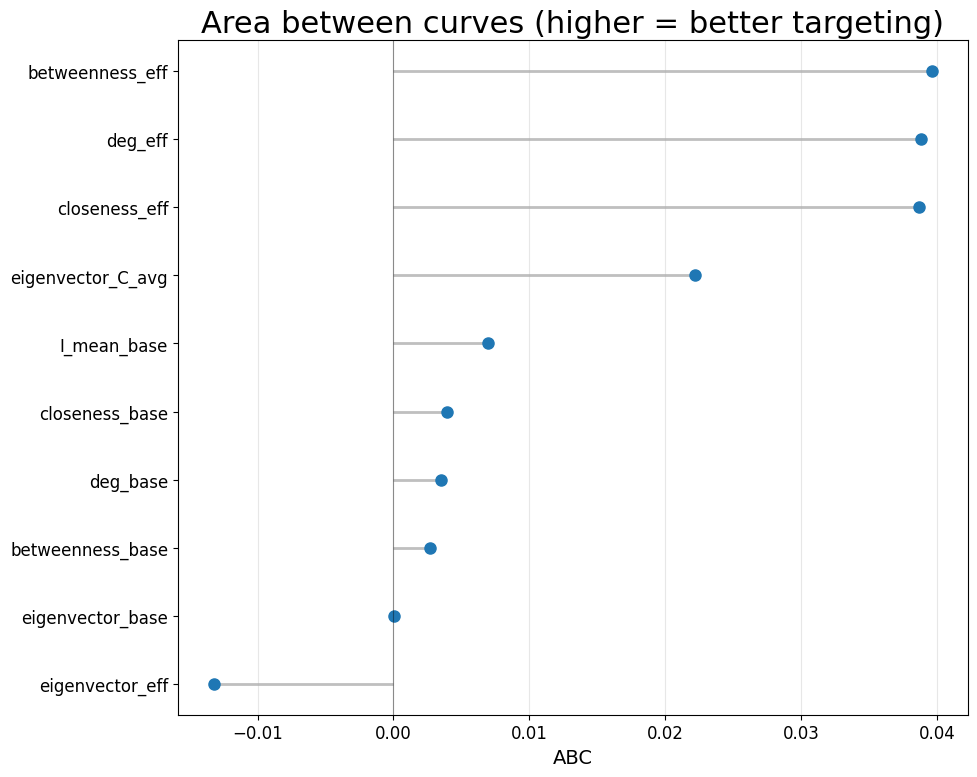

In [67]:
metrics = list(metric_scores.keys())
order = sorted(metrics, key=lambda m: metric_scores[m]["ABC"])
abc = np.array([metric_scores[m]["ABC"] for m in order])

y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(10, max(8, 0.35 * len(order))))
# Lollipop: stem + dot
ax.hlines(y, 0, abc, color="0.75", lw=2, zorder=1)
ax.plot(abc, y, "o", ms=8, color="C0", zorder=2, clip_on=False)

ax.set_yticks(y, order)
ax.set_xlabel("ABC")
ax.set_title("Area between curves (higher = better targeting)",fontsize=22)
ax.axvline(0, color="k", lw=0.8, alpha=0.4)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()